In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation 
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# Data Collection & Data information

In [3]:
data = pd.read_csv('placementdata.csv')
data
# shape tells number of rows and columns inyour datasets
data.shape
# info tells the details/summary of dataset
data.info
# check null values in datasets
print(data.isnull().sum())
# check duplicate values in datsets
print(data.duplicated().sum())
data.columns.dtype
# check is data imbalance or not
print(data["PlacementStatus"].value_counts())

StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64
0
PlacementStatus
NotPlaced    5803
Placed       4197
Name: count, dtype: int64


# Data Preprocessing



Columns After Removal:
Index(['CGPA', 'Internships', 'Projects', 'Workshops/Certifications',
       'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities',
       'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus'],
      dtype='object')

Encoded Dataset:
   CGPA  Internships  Projects  Workshops/Certifications  AptitudeTestScore  \
0   7.5            1         1                         1                 65   
1   8.9            0         3                         2                 90   
2   7.3            1         2                         2                 82   
3   7.5            1         1                         2                 85   
4   8.3            1         2                         2                 86   

   SoftSkillsRating  ExtracurricularActivities  PlacementTraining  SSC_Marks  \
0               4.4                          0                  0         61   
1               4.0                          1                  1         78   


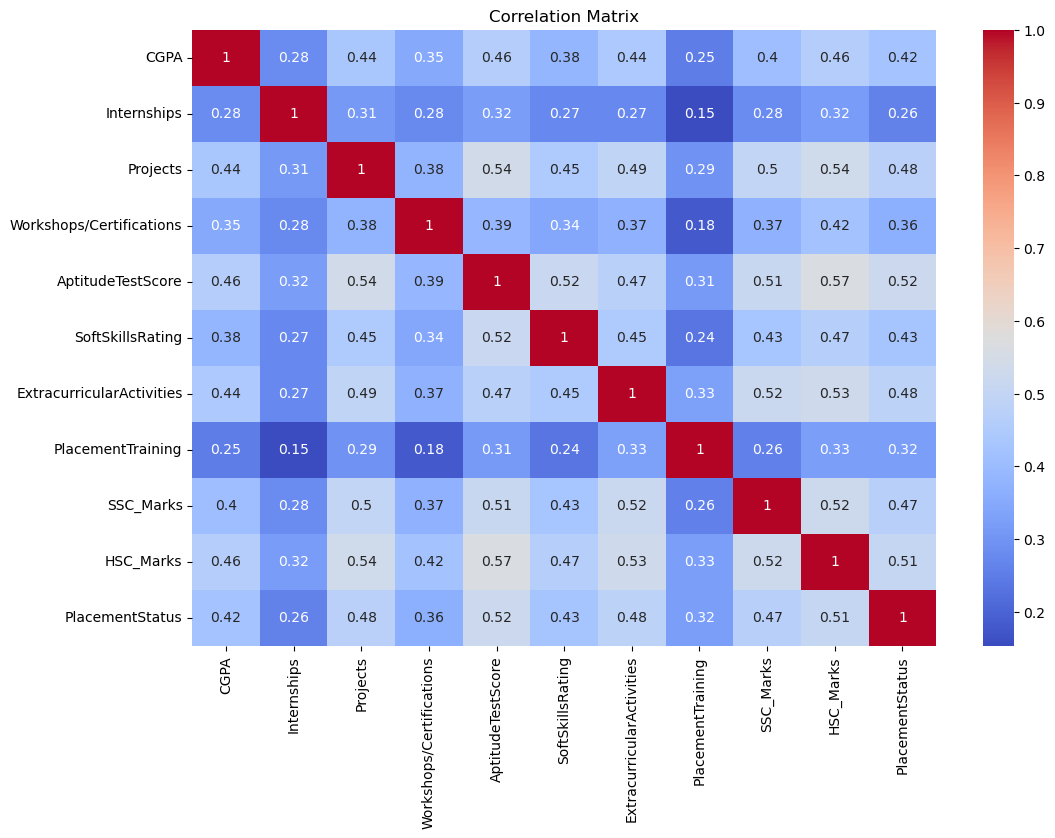

In [4]:
# Remove unnecessary columns
remove_cols = ['StudentID', 'Name', 'Email']
for col in remove_cols:
    if col in data.columns: 
        data.drop(col, axis=1, inplace=True) 
        print("\nColumns After Removal:")
        print(data.columns)

# categorize data
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

print("\nEncoded Dataset:")
print(data.head())

# correlation matrix
corr_matrix = data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

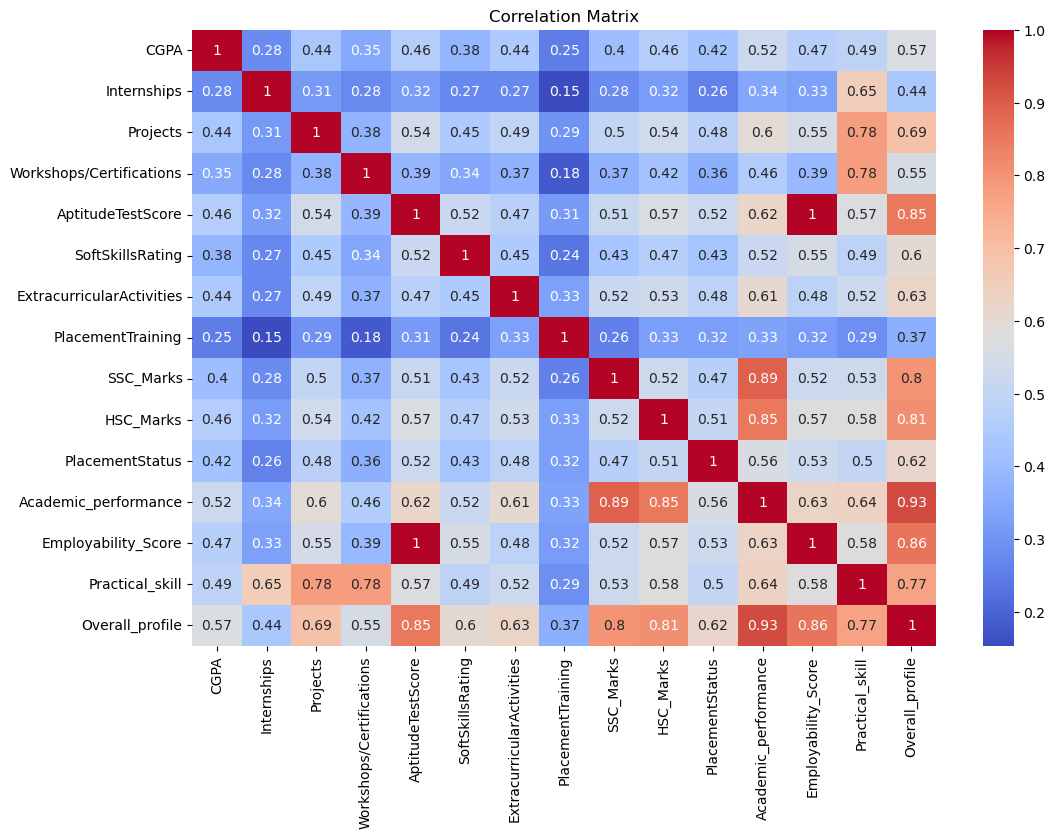

In [5]:
data['Academic_performance']= (
    data['SSC_Marks']+data['HSC_Marks']+data['CGPA']
)/3

data['Employability_Score']=(
    data['AptitudeTestScore']+data['SoftSkillsRating']
)/2

data['Practical_skill'] = (
    data['Projects']+data['Internships']+data['Workshops/Certifications']
)

data['Overall_profile'] = (
    data['Academic_performance']+ data['Employability_Score'] + data['Practical_skill']
)/3
# correlation matrix
corr_matrix = data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Selected Features

In [6]:
features = [
    'Academic_performance',
    'Employability_Score',
    'Practical_skill',
    'ExtracurricularActivities',
    'PlacementTraining'
]

# Split Datasets

In [7]:
X = data[features]
y = data["PlacementStatus"]


# Train test split

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Model Selection

In [9]:
# Logistic regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression")
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))

print(classification_report(y_test, lr_pred))
# Decision Tree
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nDecision Tree")
print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print(confusion_matrix(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest")
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))



Logistic Regression
Accuracy: 0.796
[[956 216]
 [192 636]]
              precision    recall  f1-score   support

           0       0.83      0.82      0.82      1172
           1       0.75      0.77      0.76       828

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.80      0.80      2000


Decision Tree
Accuracy: 0.72
[[878 294]
 [266 562]]
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1172
           1       0.66      0.68      0.67       828

    accuracy                           0.72      2000
   macro avg       0.71      0.71      0.71      2000
weighted avg       0.72      0.72      0.72      2000


Random Forest
Accuracy: 0.7885
[[966 206]
 [217 611]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1172
           1       0.75      0.74      0.74       828

    accuracy  

# Important Feature Selection

In [10]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                     Feature  Importance
0       Academic_performance    0.399290
1        Employability_Score    0.311265
2            Practical_skill    0.130495
3  ExtracurricularActivities    0.123846
4          PlacementTraining    0.035104


In [26]:
import pickle
pickle.dump(rf_model, open("placement_model.pkl", "wb"))
print("\nModel Saved Successfully!")


Model Saved Successfully!


In [36]:
import pickle
import pandas as pd

# Load model and scaler
model = pickle.load(open("placement_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# Sample input
sample_data = pd.DataFrame([{
    'Academic_performance': 50,
    'Employability_Score': 65,
    'Practical_skill': 75,
    'ExtracurricularActivities': 0,
    'PlacementTraining': 0
}])

# Apply scaling
sample_scaled = scaler.transform(sample_data)

# Prediction
prediction = model.predict(sample_scaled)

print("student placement chance :",prediction)
# Placement Probability
probability = model.predict_proba(sample_scaled)

placement_chance = probability[0][1] * 100

print(
    "\nPlacement Probability:",
    round(placement_chance, 2),
    "%"
)

# Readiness Score
readiness_score = (
    sample_data['Academic_performance'][0] * 0.4 +
    sample_data['Employability_Score'][0] * 0.4 +
    sample_data['Practical_skill'][0] * 0.2
)

print(
    "\nPlacement Readiness Score:",
    round(readiness_score, 2)
)

# Readiness Level
if placement_chance >= 80:
    print("Placement Readiness: Excellent")

elif placement_chance >= 60:
    print("Placement Readiness: Good")

elif placement_chance >= 40:
    print("Placement Readiness: Moderate")

else:
    print("Placement Readiness: Needs Improvement")


# Recommendations
if sample_data['Practical_skill'][0] < 50:
    print("Recommendation: Improve projects and internships")

if sample_data['Employability_Score'][0] < 60:
    print("Recommendation: Improve aptitude and communication skills")

if sample_data['Academic_performance'][0] < 60:
    print("Recommendation: Improve academic performance")

student placement chance : [0]

Placement Probability: 37.35 %

Placement Readiness Score: 61.0
Placement Readiness: Needs Improvement
Recommendation: Improve academic performance
